In [ ]:
import numpy as np
a=np.array([[4,2],[2,3]])
b=np.array([[2,0,0],[0,3,4],[0,4,3]])
#print(b)
eigenvalues, eigenvectors = np.linalg.eig(a)
#eigenvalues, eigenvectors = np.linalg.eig(b)
print(eigenvalues)
print(eigenvectors)

[5.56155281 1.43844719]
[[ 0.78820544 -0.61541221]
 [ 0.61541221  0.78820544]]


In [ ]:
import numpy as np
C = np.array([[3, 1], [1, 3]])
U, S, Vt = np.linalg.svd(C)
print("U =")
print(U)
print("Σ =")
print(np.diag(S))
print("V^T =")
print(Vt)

U =
[[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]
Σ =
[[4. 0.]
 [0. 2.]]
V^T =
[[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]


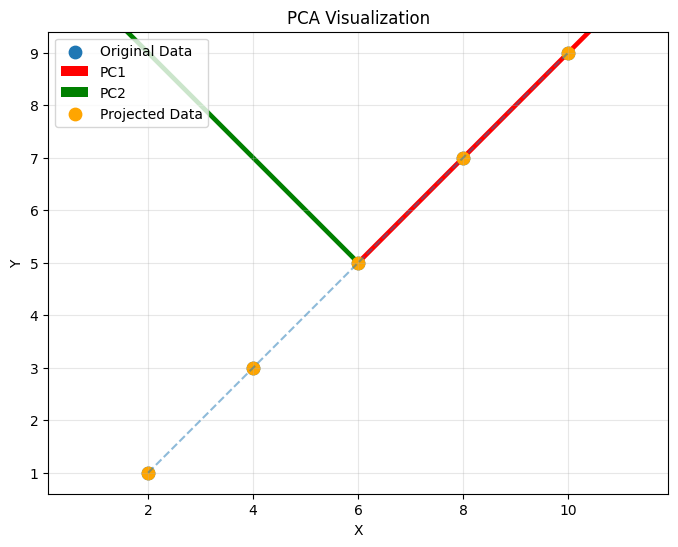

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.array([2, 4, 6, 8, 10])
Y = np.array([1, 3, 5, 7, 9])
data = np.column_stack((X, Y))

# Center data
mean = data.mean(axis=0)
Z = data - mean

# Covariance + Eigen decomposition
eigvals, eigvecs = np.linalg.eig(np.cov(Z, rowvar=False))
idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, idx]

# Projection
Z_pca = Z @ eigvecs

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, label="Original Data", s=80)
plt.plot(X, Y, '--', alpha=0.5)

plt.quiver(*mean, *eigvecs[:, 0], scale=1, color='r', label='PC1')
plt.quiver(*mean, *eigvecs[:, 1], scale=1, color='g', label='PC2')

plt.scatter(Z_pca[:, 0]*eigvecs[0,0] + mean[0],
            Z_pca[:, 0]*eigvecs[1,0] + mean[1],
            color='orange', label='Projected Data', s=80)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("PCA Visualization")
plt.legend()
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()

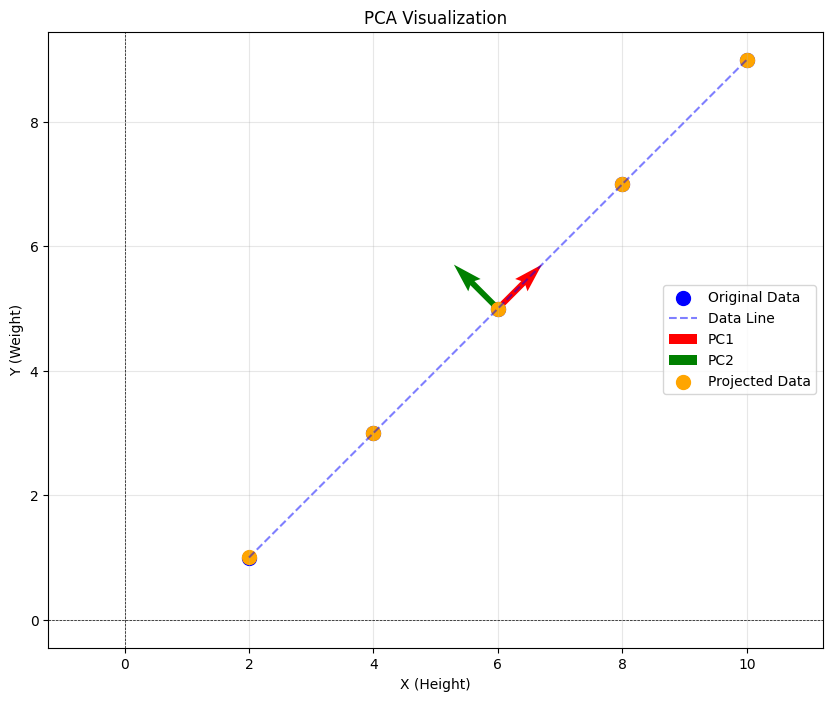

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define the dataset
X = np.array([2, 4, 6, 8, 10])  # First variable (e.g., height)
Y = np.array([1, 3, 5, 7, 9])   # Second variable (e.g., weight)

# Step 2: Center the data
X_centered = X - np.mean(X)
Y_centered = Y - np.mean(Y)
centered_data = np.vstack((X_centered, Y_centered)).T  # Shape: (n_samples, n_features)

# Step 3: Compute the covariance matrix
cov_matrix = np.cov(centered_data, rowvar=False)  # rowvar=False means columns are variables

# Step 4: Perform eigenvalue decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Step 5: Sort eigenvalues and eigenvectors
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort in descending order
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Extract principal components
pc1 = eigenvectors[:, 0]  # First principal component
pc2 = eigenvectors[:, 1]  # Second principal component

# Step 6: Project data onto the principal components
transformed_data = centered_data @ eigenvectors  # Project data onto new axes

# Step 7: Plotting
plt.figure(figsize=(10, 8))

# Plot original data points
plt.scatter(X, Y, color='blue', label='Original Data', s=100)
plt.plot(X, Y, color='blue', linestyle='--', alpha=0.5, label='Data Line')

# Plot principal axes
origin = np.mean(X), np.mean(Y)  # Mean of the data (center point)
plt.quiver(*origin, pc1[0], pc1[1], angles='xy', scale_units='xy', scale=1, color='red', label='PC1')
plt.quiver(*origin, pc2[0], pc2[1], angles='xy', scale_units='xy', scale=1, color='green', label='PC2')

# Plot transformed data along PC1
plt.scatter(transformed_data[:, 0] * pc1[0] + origin[0],
            transformed_data[:, 0] * pc1[1] + origin[1],
            color='orange', label='Projected Data', s=100)

# Add labels and legend
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.xlabel('X (Height)')
plt.ylabel('Y (Weight)')
plt.title('PCA Visualization')
plt.legend()
plt.grid(alpha=0.3)

# Show the plot
plt.axis('equal')  # Ensure equal scaling for x and y axes
plt.show()


In [ ]:
import numpy as np

X = np.array([[2,1],[4,3],[6,5],[8,7],[10,9]])

Xc = X - X.mean(axis=0)          # Center data
U, S, Vt = np.linalg.svd(Xc)     # SVD
X_pca = Xc @ Vt.T                # PCA projection

print(X_pca)

[[-5.65685425e+00 -4.44089210e-16]
 [-2.82842712e+00 -2.22044605e-16]
 [ 0.00000000e+00  0.00000000e+00]
 [ 2.82842712e+00  2.22044605e-16]
 [ 5.65685425e+00  4.44089210e-16]]


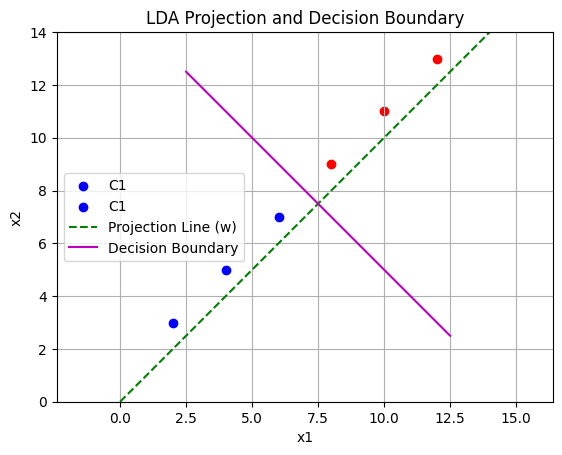

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Original data
X = np.array([[2, 3], [4, 5], [6, 7], [8, 9], [10, 11], [12, 13]])
y = np.array([0, 0, 0, 1, 1, 1])  # 0 for C1, 1 for C2

# Projected values (from your table)
z = np.array([3.5355, 6.3640, 9.1924, 12.0208, 14.8492, 17.6777])

# Colors for the classes
colors = ['blue', 'red']

# Plot the original data
for i in range(len(X)):
    plt.scatter(X[i, 0], X[i, 1], c=colors[y[i]], label=f'C{y[i]+1}' if i < 2 else "")

# Plot the projection line (w = [1, 1])
w = np.array([1, 1])
plt.plot([0, 15], [0, 15], '--g', label='Projection Line (w)') # Adjust 15 to fit plot limits

# Calculate means of projected values
mean_z_c1 = np.mean(z[y == 0])
mean_z_c2 = np.mean(z[y == 1])

# Calculate midpoint for decision boundary
midpoint_z = (mean_z_c1 + mean_z_c2) / 2

# Convert midpoint_z back to x, y on the line x=y
midpoint_x = midpoint_z / np.sqrt(2)

# Plot the decision boundary (perpendicular to w)
plt.plot([midpoint_x - 5, midpoint_x + 5], [midpoint_x + 5, midpoint_x - 5], '-m', label='Decision Boundary') # Adjust 5 to fit plot limits

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('LDA Projection and Decision Boundary')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.xlim(0, 14) # Adjust limits as needed
plt.ylim(0, 14) # Adjust limits as needed
plt.show()


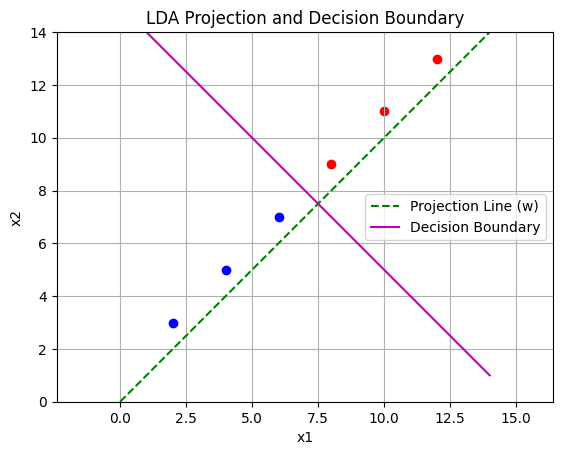

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Original data
X = np.array([[2, 3], [4, 5], [6, 7],
              [8, 9], [10, 11], [12, 13]])
y = np.array([0, 0, 0, 1, 1, 1])

# Unit projection vector
w = np.array([1, 1]) / np.sqrt(2)

# Compute projections properly
z = X @ w

# Plot data
colors = ['blue', 'red']
for i in range(len(X)):
    plt.scatter(X[i, 0], X[i, 1], c=colors[y[i]])

# Projection line (x2 = x1)
x_vals = np.linspace(0, 14, 100)
plt.plot(x_vals, x_vals, '--g', label='Projection Line (w)')

# Compute class means in projected space
mean_z_c1 = np.mean(z[y == 0])
mean_z_c2 = np.mean(z[y == 1])

# Midpoint
midpoint_z = (mean_z_c1 + mean_z_c2) / 2

# Decision boundary: x2 = c - x1
c = midpoint_z * np.sqrt(2)
plt.plot(x_vals, c - x_vals, '-m', label='Decision Boundary')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('LDA Projection and Decision Boundary')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.xlim(0, 14)
plt.ylim(0, 14)
plt.show()


In [13]:
import numpy as np
#Rating Matrix
R = np.array([[5,3],[4,0]])
print(R)
#lATENT matrices
U= np.array([[1,0.5],[0.6,0.2]])
print(U)
V= np.array([[1,0.4],[0.8,0.3]])
print(V)
#Parameters
Alpha = 0.01      #learning rate
lam = 0.1         #regularization
#prediction
#predict rating for user 2, item2
pred =np.dot(U[1],V[1])
print(pred)
#error
actual =2
error = actual - pred
print(error)
squared_error =error**2
print(squared_error)
#gradient update for U2
U2_old = U[1].copy()
U[1] = U[1]+Alpha*(error*V[1]-lam*U[1])
print(U[1])
#updated full prediction matrix
R_pred=np.dot(U,V.T)
print(R_pred)

[[5 3]
 [4 0]]
[[1.  0.5]
 [0.6 0.2]]
[[1.  0.4]
 [0.8 0.3]]
0.54
1.46
2.1315999999999997
[0.61108 0.20418]
[[1.2      0.95    ]
 [0.692752 0.550118]]
